# GRM with PyMC

Graded Response Model (Samejima, 1969) — polytomous IRT for ordered categories.

## Cumulative response probability

$$
P^*(u_{ij} \geq k \mid \theta_i) = \frac{1}{1 + \exp\bigl(-a_j (\theta_i - b_{jk})\bigr)}
\quad k = 1, \ldots, K-1
$$

## Category probability

$$
P(u_{ij} = k \mid \theta_i) = P^*(u_{ij} \geq k) - P^*(u_{ij} \geq k+1)
$$

with $P^*(u_{ij} \geq 0) = 1$ and $P^*(u_{ij} \geq K) = 0$.

- $\theta_i$: ability of respondent $i$
- $a_j > 0$: discrimination of item $j$
- $b_{j1} < b_{j2} < \cdots < b_{j,K-1}$: ordered threshold parameters of item $j$

## Priors

$$
\theta_i \sim \mathcal{N}(0,1), \quad
a_j \sim \text{LogNormal}(0, 0.5)
$$

Ordering is enforced via a **cumulative-sum reparameterization**:

$$
b_{j1} \sim \mathcal{N}(0,1), \quad
\delta_{jk} \sim \text{HalfNormal}(1), \quad
b_{jk} = b_{j1} + \sum_{l=1}^{k-1} \delta_{jl}
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import pytensor.tensor as pt
import arviz as az

## Data Generation

Same sample data as the Stan notebook (seed=42).

In [2]:
rng = np.random.default_rng(42)

N = 100  # respondents
J = 20   # items
K = 4    # ordered response categories: 0, 1, 2, 3

# True parameters
theta_true = rng.normal(0, 1, N)
a_true = rng.lognormal(0, 0.5, J)
b_true = np.sort(rng.normal(0, 1, (J, K - 1)), axis=1)  # (J, K-1) ordered

# P*(Y >= k) for k=1,...,K-1 — shape (N, J, K-1)
eta = a_true[None, :, None] * (theta_true[:, None, None] - b_true[None, :, :])
cum_p = 1 / (1 + np.exp(-eta))

# Category probabilities — shape (N, J, K)
probs = np.concatenate([
    1 - cum_p[:, :, 0:1],
    cum_p[:, :, :-1] - cum_p[:, :, 1:],
    cum_p[:, :, -1:],
], axis=2)

# Sample responses via inverse CDF
u = rng.uniform(size=(N, J, 1))
Y = (u > np.cumsum(probs, axis=2)).sum(axis=2).astype(int)  # (N, J)

print(f"Response matrix shape: {Y.shape}")
print(f"Category counts: {np.bincount(Y.ravel())}")
print(f"True a range: [{a_true.min():.2f}, {a_true.max():.2f}]")
print(f"True b[:,0] range: [{b_true[:,0].min():.2f}, {b_true[:,0].max():.2f}]")

Response matrix shape: (100, 20)
Category counts: [696 294 294 716]
True a range: [0.42, 2.23]
True b[:,0] range: [-2.13, 0.41]


## PyMC Model

The ordered constraint is enforced by parameterizing thresholds as
$b_{jk} = b_{j1} + \sum_{l=1}^{k-1}\delta_{jl}$ with $\delta_{jl} > 0$.
This lets the sampler work in unconstrained space without sorting.

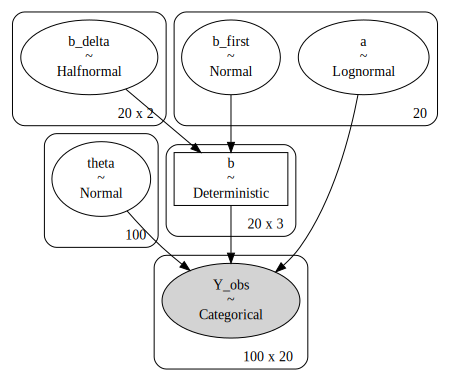

In [3]:
with pm.Model() as model_grm:
    # Priors
    theta = pm.Normal("theta", mu=0, sigma=1, shape=N)
    a = pm.LogNormal("a", mu=0, sigma=0.5, shape=J)

    # Ordered thresholds via cumulative-sum reparameterization
    # b_first: (J,)  — first threshold per item
    # b_delta: (J, K-2) — positive increments
    b_first = pm.Normal("b_first", mu=0, sigma=1, shape=J)
    b_delta = pm.HalfNormal("b_delta", sigma=1, shape=(J, K - 2))
    b = pm.Deterministic(
        "b",
        pt.concatenate(
            [b_first[:, None], b_first[:, None] + pt.cumsum(b_delta, axis=1)],
            axis=1,
        ),
    )  # (J, K-1), guaranteed ordered

    # Linear predictor — shape (N, J, K-1)
    eta = a[None, :, None] * (theta[:, None, None] - b[None, :, :])

    # P*(Y >= k) for k=1,...,K-1
    cum_p_model = pm.math.sigmoid(eta)  # (N, J, K-1)

    # Category probabilities — shape (N, J, K)
    p = pt.concatenate(
        [
            1 - cum_p_model[:, :, 0:1],
            cum_p_model[:, :, :-1] - cum_p_model[:, :, 1:],
            cum_p_model[:, :, -1:],
        ],
        axis=2,
    )

    Y_obs = pm.Categorical("Y_obs", p=p, observed=Y)

pm.model_to_graphviz(model_grm)

## Sampling

In [4]:
with model_grm:
    idata = pm.sample(
        1000,
        tune=1000,
        chains=4,
        target_accept=0.9,
        random_seed=42,
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [theta, a, b_first, b_delta]
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encountered in accumulate
  outputs = vm() if output_subset is None else vm(output_subset=output_subset)
/home/mitama/bayesian-irt-models/.venv/lib/python3.12/site-packages/pytensor/compile/function/types.py:1038: RuntimeWarning: invalid value encoun

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 12 seconds.


## Results

In [5]:
az.summary(idata, var_names=["a", "b"], round_to=2)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
a[0],0.58,0.15,0.33,0.85,0.00,0.00,2816.78,2710.00,1.0
a[1],1.34,0.34,0.74,1.99,0.01,0.01,2659.29,2859.45,1.0
a[2],0.91,0.20,0.56,1.29,0.00,0.00,2196.61,2501.04,1.0
a[3],1.50,0.35,0.87,2.15,0.01,0.01,2042.39,2226.79,1.0
a[4],0.70,0.19,0.37,1.05,0.00,0.00,2183.57,2224.29,1.0
...,...,...,...,...,...,...,...,...,...
"b[18, 1]",0.46,0.14,0.21,0.73,0.00,0.00,1442.47,2628.28,1.0
"b[18, 2]",1.58,0.23,1.15,1.99,0.01,0.00,1716.98,2131.82,1.0
"b[19, 0]",-0.11,0.35,-0.78,0.53,0.01,0.01,2760.03,2356.25,1.0
"b[19, 1]",0.31,0.36,-0.36,0.98,0.01,0.01,3496.48,2578.59,1.0


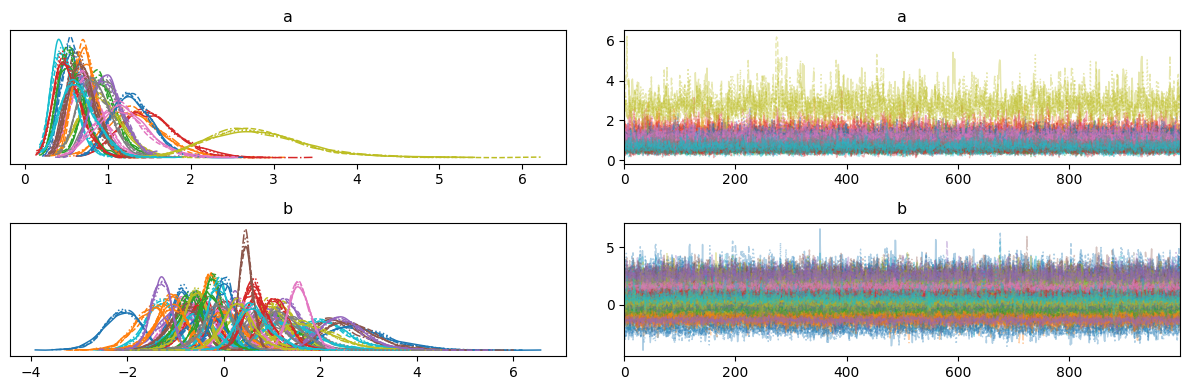

In [6]:
az.plot_trace(idata, var_names=["a", "b"], compact=True)
plt.tight_layout()
plt.show()

## Comparison: Estimated vs True Parameters

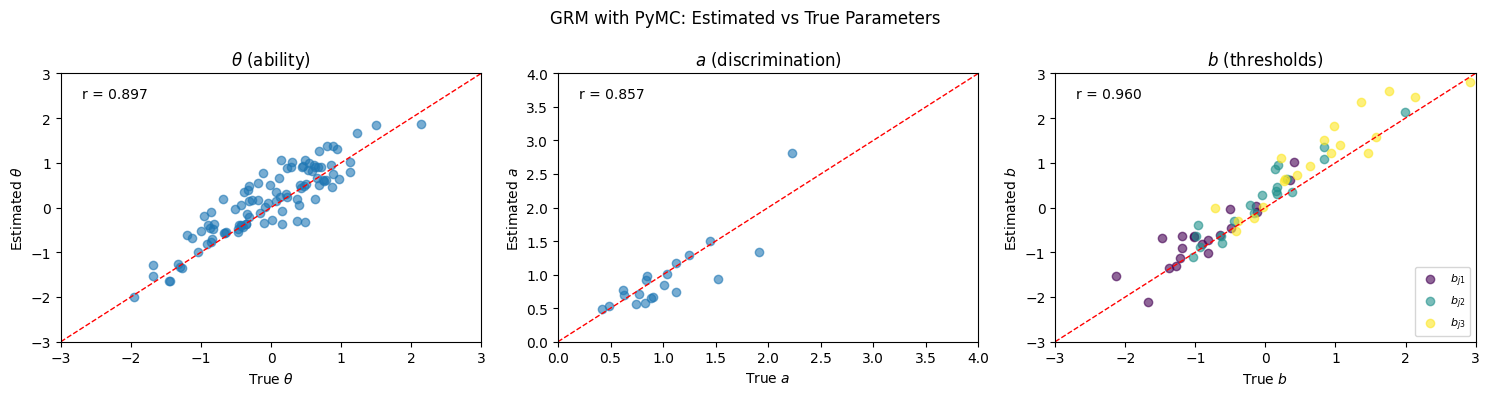

In [7]:
theta_est = idata.posterior["theta"].mean(dim=["chain", "draw"]).values  # (N,)
a_est = idata.posterior["a"].mean(dim=["chain", "draw"]).values           # (J,)
b_est = idata.posterior["b"].mean(dim=["chain", "draw"]).values           # (J, K-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# theta
axes[0].scatter(theta_true, theta_est, alpha=0.6)
axes[0].plot([-3, 3], [-3, 3], "r--", lw=1)
axes[0].set(xlim=(-3, 3), ylim=(-3, 3),
            xlabel=r"True $\theta$", ylabel=r"Estimated $\theta$",
            title=r"$\theta$ (ability)")
axes[0].text(0.05, 0.95, f"r = {np.corrcoef(theta_true, theta_est)[0,1]:.3f}",
             transform=axes[0].transAxes, va="top")

# a
axes[1].scatter(a_true, a_est, alpha=0.6)
axes[1].plot([0, 4], [0, 4], "r--", lw=1)
axes[1].set(xlim=(0, 4), ylim=(0, 4),
            xlabel=r"True $a$", ylabel=r"Estimated $a$",
            title=r"$a$ (discrimination)")
axes[1].text(0.05, 0.95, f"r = {np.corrcoef(a_true, a_est)[0,1]:.3f}",
             transform=axes[1].transAxes, va="top")

# b — all J*(K-1) threshold pairs, colored by threshold index
colors = plt.cm.viridis(np.linspace(0, 1, K - 1))
for k in range(K - 1):
    axes[2].scatter(b_true[:, k], b_est[:, k], alpha=0.6,
                    color=colors[k], label=f"$b_{{j{k+1}}}$")
axes[2].plot([-3, 3], [-3, 3], "r--", lw=1)
axes[2].set(xlim=(-3, 3), ylim=(-3, 3),
            xlabel=r"True $b$", ylabel=r"Estimated $b$",
            title=r"$b$ (thresholds)")
axes[2].legend(fontsize=8)
b_corr = np.corrcoef(b_true.ravel(), b_est.ravel())[0, 1]
axes[2].text(0.05, 0.95, f"r = {b_corr:.3f}",
             transform=axes[2].transAxes, va="top")

plt.suptitle("GRM with PyMC: Estimated vs True Parameters")
plt.tight_layout()
plt.show()